In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
df = pd.read_csv('google_playstore.csv')
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Released,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",0,Everyone,Art & Design,"Aughust 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10841 non-null  int64  
 1   App             10841 non-null  str    
 2   Category        10841 non-null  str    
 3   Rating          9367 non-null   float64
 4   Reviews         10841 non-null  str    
 5   Size            10841 non-null  str    
 6   Installs        10841 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Released        10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 1.1 MB


In [3]:
# summary of the dataset
df.describe()

,Unnamed: 0,Rating
count,10841.000000,9367.000000
mean,5420.000000,4.193338
std,3129.671468,0.537431
min,0.000000,1.000000
25%,2710.000000,4.000000
50%,5420.000000,4.300000
75%,8130.000000,4.500000
max,10840.000000,19.000000


In [4]:
# missing values in the dataset
df.isnull().sum()

Unnamed: 0           0
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Price                0
Content Rating       1
Genres               0
Released             0
Current Ver          8
Android Ver          3
dtype: int64

In [5]:
df['Reviews'].unique()

<StringArray>
[   '159',    '967',  '87510', '215644',    '167',    '178',  '36815',
  '13791',    '121',  '13880',
 ...
   '2036',  '56496', '376223',    '785',   '5775',    '885',  '88486',
    '603',   '1195', '398307']
Length: 6002, dtype: str

In [6]:
df['Reviews'].str.isnumeric().sum()

np.int64(10840)

In [8]:
df[~df['Reviews'].str.isnumeric()]

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Released,Current Ver,Android Ver
10472,10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [9]:
df_copy = df.copy()

In [10]:
df_copy = df_copy.drop(df_copy.index[10472])

In [12]:
df_copy[~df_copy['Reviews'].str.isnumeric()]

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Released,Current Ver,Android Ver


In [13]:
# convert reviews to numeric
df_copy['Reviews'] = df_copy['Reviews'].astype(int)

In [14]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10840 non-null  int64  
 1   App             10840 non-null  str    
 2   Category        10840 non-null  str    
 3   Rating          9366 non-null   float64
 4   Reviews         10840 non-null  int64  
 5   Size            10840 non-null  str    
 6   Installs        10840 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Released        10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 1.2 MB


In [15]:
import numpy as np

In [16]:
df_copy['Size'] = df_copy['Size'].str.replace('M', '000')
df_copy['Size'] = df_copy['Size'].str.replace('k', '')
df_copy['Size'] = df_copy['Size'].replace('Varies with device', np.nan)
df_copy['Size'] = df_copy['Size'].astype(float)

In [18]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10840 non-null  int64  
 1   App             10840 non-null  str    
 2   Category        10840 non-null  str    
 3   Rating          9366 non-null   float64
 4   Reviews         10840 non-null  int64  
 5   Size            9145 non-null   float64
 6   Installs        10840 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Released        10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(2), int64(2), str(9)
memory usage: 1.2 MB


In [19]:
df['Installs'].unique()

<StringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0',           'Free']
Length: 22, dtype: str

In [20]:
chars_to_remove = ['+', ',', '$']
cols_to_clean = ['Installs', 'Price']
for item in chars_to_remove:
    for col in cols_to_clean:
        df_copy[col] = df_copy[col].str.replace(item, '', regex=False)

In [21]:
df_copy['Installs'].unique()

<StringArray>
[     '10000',     '500000',    '5000000',   '50000000',     '100000',
      '50000',    '1000000',   '10000000',       '5000',  '100000000',
 '1000000000',       '1000',  '500000000',         '50',        '100',
        '500',         '10',          '1',          '5',          '0']
Length: 20, dtype: str

In [22]:
df_copy['Installs'] = df_copy['Installs'].astype(int)
df_copy['Price'] = df_copy['Price'].astype(float)

In [23]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10840 non-null  int64  
 1   App             10840 non-null  str    
 2   Category        10840 non-null  str    
 3   Rating          9366 non-null   float64
 4   Reviews         10840 non-null  int64  
 5   Size            9145 non-null   float64
 6   Installs        10840 non-null  int64  
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Released        10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(3), int64(3), str(7)
memory usage: 1.2 MB


In [24]:
# Handling Released feature
df_copy['Released'].unique()

<StringArray>
[   'January 7, 2018',   'January 15, 2018',    'Aughust 1, 2018',
       'June 8, 2018',      'June 20, 2018',     'March 26, 2017',
     'April 26, 2018',      'June 14, 2018', 'Septemter 20, 2017',
       'July 3, 2018',
 ...
  'November 23, 2015',      'June 17, 2012',  'February 27, 2015',
  'December 18, 2013',   'February 6, 2012',  'November 25, 2014',
       'May 19, 2016',   'January 20, 2014',  'February 16, 2014',
     'March 23, 2014']
Length: 1377, dtype: str

In [27]:
from difflib import get_close_matches

MONTHS = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]

def fix_month(date_str):
    parts = date_str.split()
    month = parts[0]
    close = get_close_matches(month.capitalize(), MONTHS, n=1, cutoff=0.6)
    if close:
        parts[0] = close[0]
    return ' '.join(parts)

df_copy['Released'] = df['Released'].apply(fix_month)

In [28]:
df_copy['Released'] = pd.to_datetime(df_copy['Released'], format='%B %d, %Y')
df_copy['Day'] = df_copy['Released'].dt.day
df_copy['Month'] = df_copy['Released'].dt.month
df_copy['Year'] = df_copy['Released'].dt.year

In [30]:
df_copy.head(2)

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Released,Current Ver,Android Ver,Day,Month,Year
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


In [31]:
df_copy.to_csv('google_playstore_cleaned.csv', index=False)

EDA

In [33]:
df[df.duplicated('App')]

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Released,Current Ver,Android Ver
229,229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,239,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,261,join.me - Simple Meetings,BUSINESS,4.0,6989,Varies with device,"1,000,000+",0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10715,10715,FarmersOnly Dating,DATING,3.0,1145,1.4M,"100,000+",0,Mature 17+,Dating,"February 25, 2016",2.2,4.0 and up
10720,10720,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0M,"1,000,000+",0,Everyone,Communication,"July 6, 2018",5.2,5.0 and up
10730,10730,FP Notebook,MEDICAL,4.5,410,60M,"50,000+",0,Everyone,Medical,"March 24, 2018",2.1.0.372,4.4 and up
10753,10753,Slickdeals: Coupons & Shopping,SHOPPING,4.5,33599,12M,"1,000,000+",0,Everyone,Shopping,"July 30, 2018",3.9,4.4 and up


In [ ]:
# Observations: The dataset has duplicate records. We can drop the duplicates and keep only the first occurrence of each app.

In [34]:
df_copy = df_copy.drop_duplicates(subset=['App'], keep='first')

In [35]:
df_copy.shape

(9659, 16)

Explore Data

In [36]:
numeric_cols = df_copy.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_copy.select_dtypes(include=['object']).columns

# print the numeric and categorical columns
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: Index(['Unnamed: 0', 'Rating', 'Reviews', 'Size', 'Installs', 'Price'], dtype='str')
Categorical columns: Index(['App', 'Category', 'Content Rating', 'Genres', 'Current Ver',
       'Android Ver'],
      dtype='str')


/tmp/ipykernel_44899/3868529555.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_copy.select_dtypes(include=['object']).columns


In [37]:
# proportion of count data in categorical columns
for col in categorical_cols:
    print(f"Value counts for {col}:")
    print(df_copy[col].value_counts(normalize=True)*100)
    print("\n")

Value counts for App:
App
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
Pixel Draw - Number Art Coloring Book                 0.010353
                                                        ...   
Sya9a Maroc - FR                                      0.010353
Fr. Mike Schmitz Audio Teachings                      0.010353
Parkinson Exercices FR                                0.010353
The SCP Foundation DB fr nn5n                         0.010353
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Name: proportion, Length: 9659, dtype: float64


Value counts for Category:
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.89274

/tmp/ipykernel_44899/1212194349.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[numeric_cols[i]], shade=True, color='blue')
/tmp/ipykernel_44899/1212194349.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[numeric_cols[i]], shade=True, color='blue')
/tmp/ipykernel_44899/1212194349.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[numeric_cols[i]], shade=True, color='blue')
/tmp/ipykernel_44899/1212194349.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_c

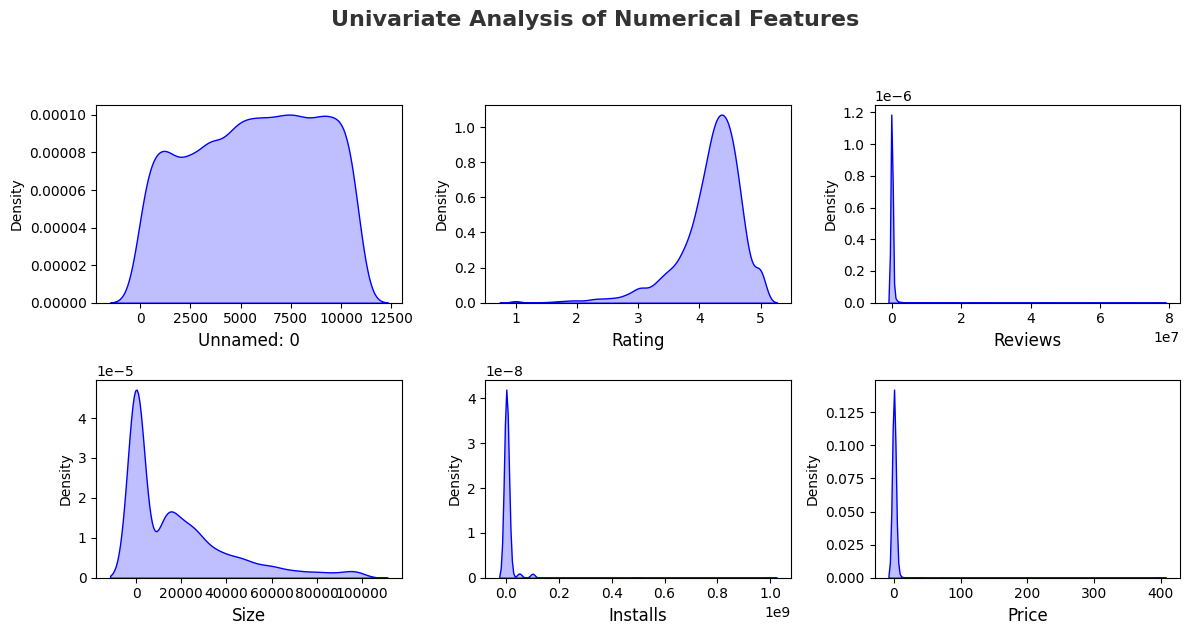

In [39]:
# visualize the same
plt.figure(figsize=(12, 6))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=16, fontweight='bold', alpha=0.8, y=1.05)

for i in range(len(numeric_cols)):
    plt.subplot(2, 3, i+1)
    sns.kdeplot(x=df_copy[numeric_cols[i]], shade=True, color='blue')
    plt.xlabel(numeric_cols[i], fontsize=12)
    plt.tight_layout()

/tmp/ipykernel_44899/3996268008.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_copy[category[i]], palette='Set2')
/tmp/ipykernel_44899/3996268008.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_copy[category[i]], palette='Set2')


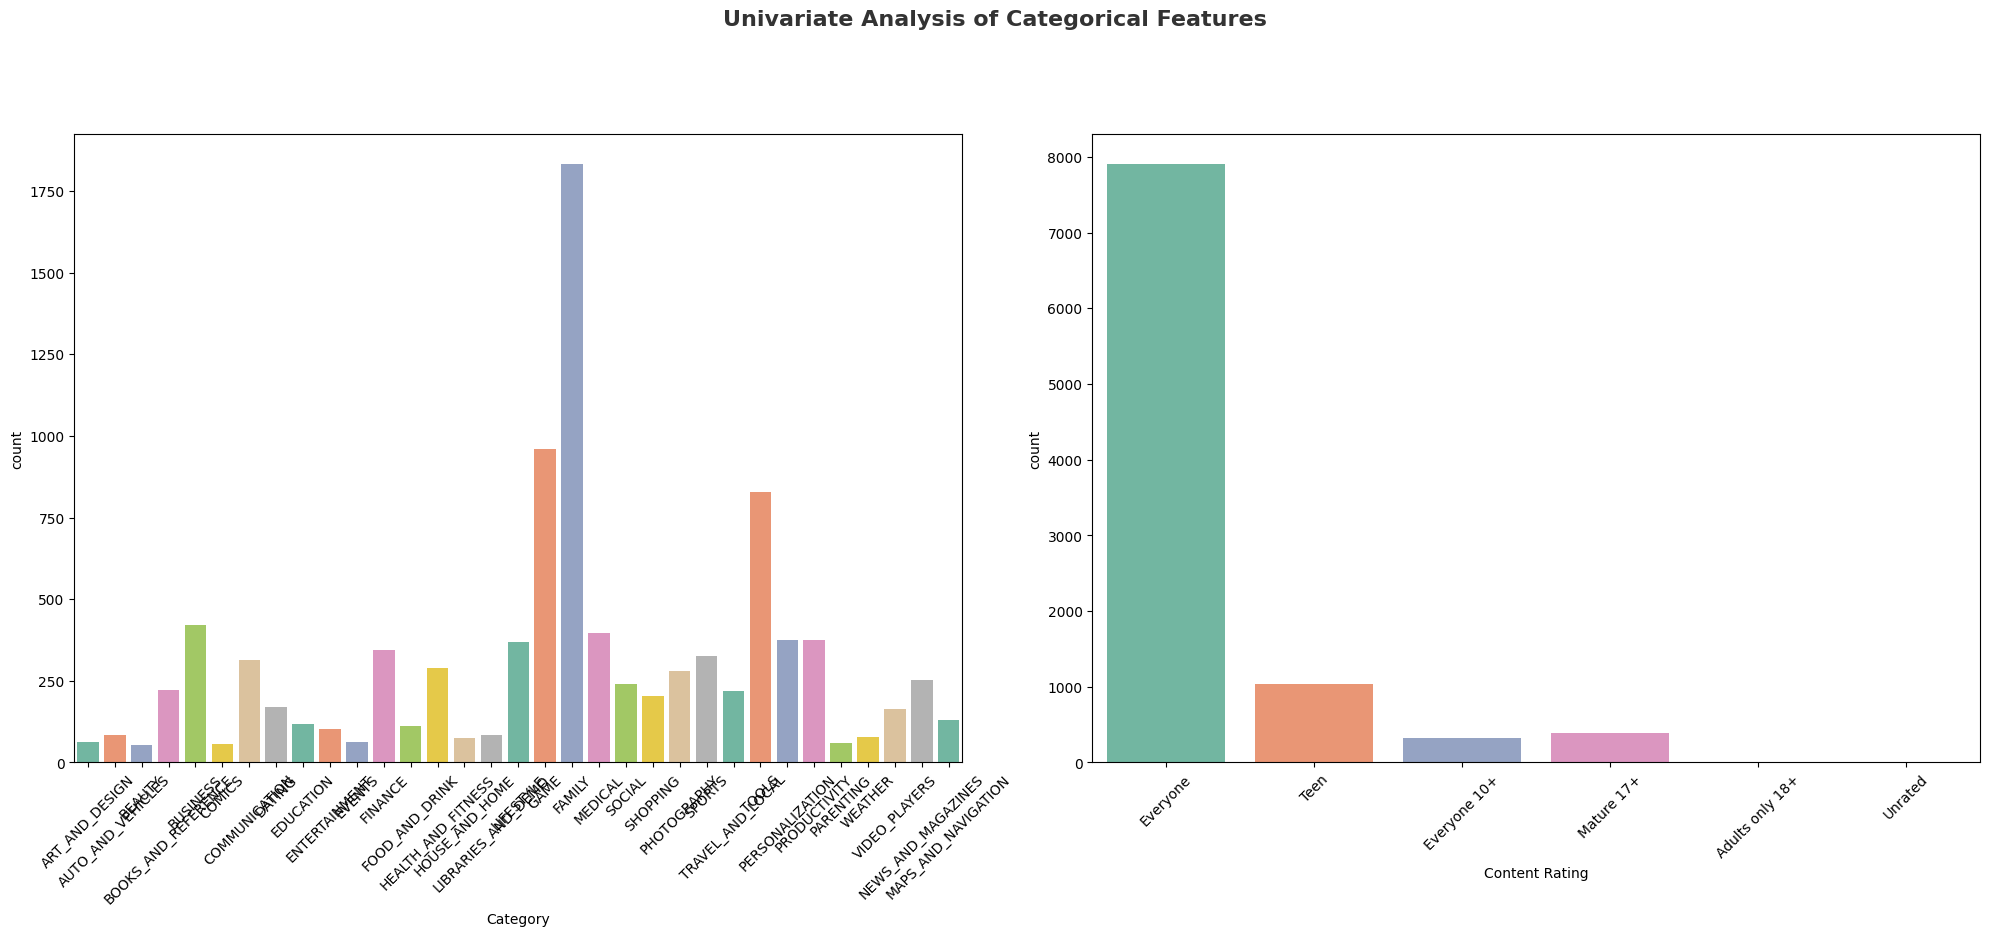

In [45]:
# categorical features
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=16, fontweight='bold', alpha=0.8, y=1.05)
category = ['Category', 'Content Rating']

for i in range(len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df_copy[category[i]], palette='Set2')
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

In [46]:
## Which is the most popular app category?
df_copy.head(2)

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Released,Current Ver,Android Ver,Day,Month,Year
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


<Axes: >

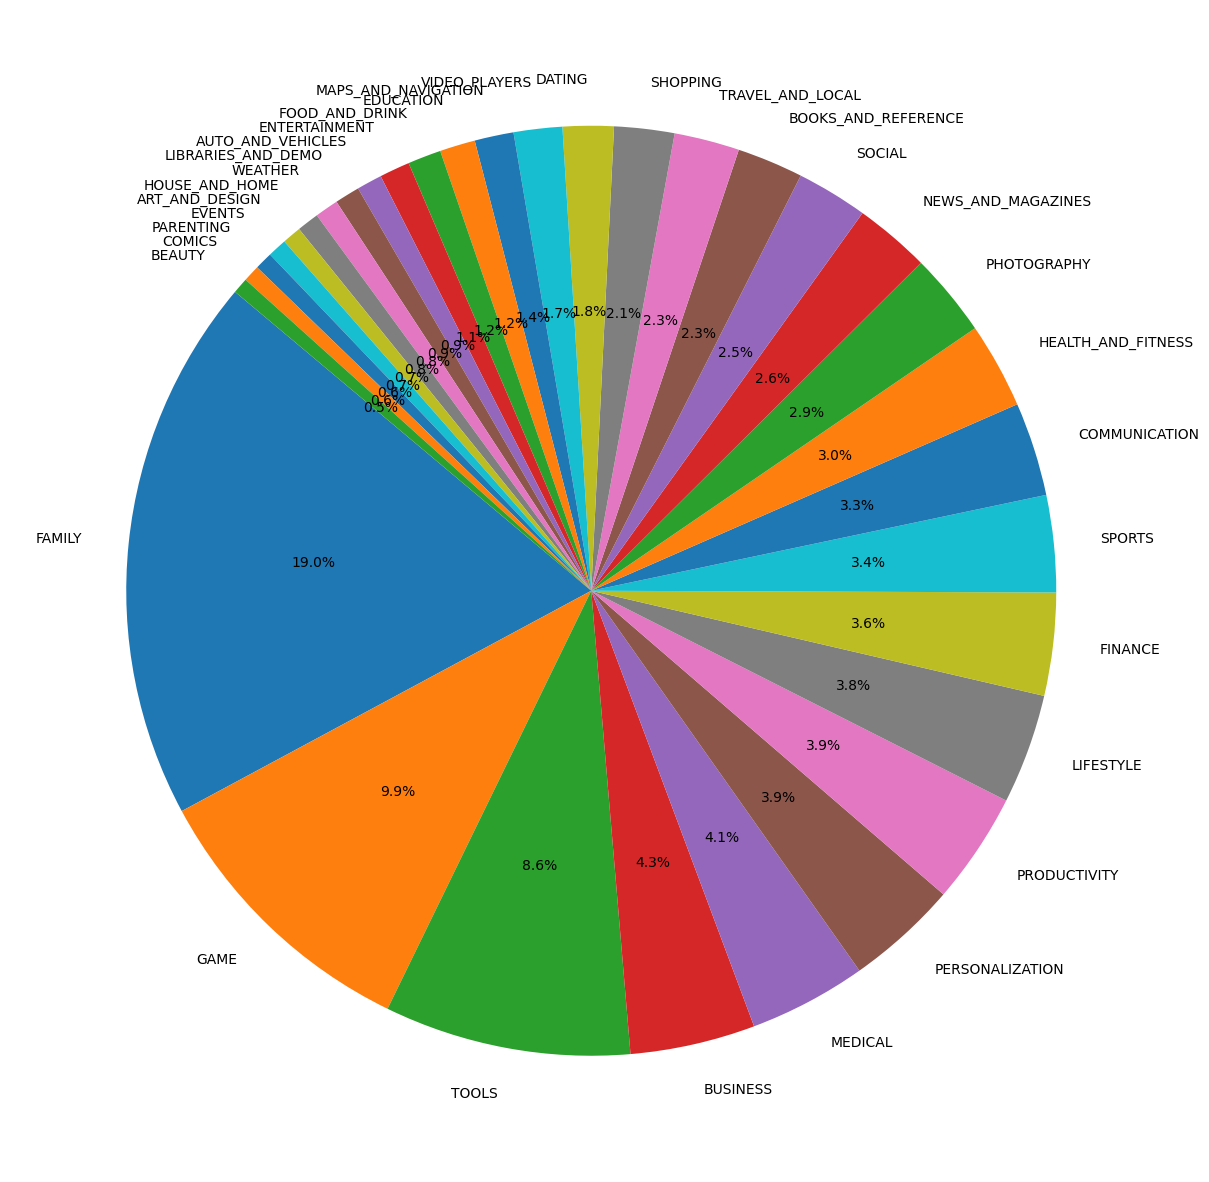

In [48]:
df_copy['Category'].value_counts().plot.pie(df['Category'],figsize=(15,16), autopct='%1.1f%%', startangle=140)

In [49]:
# Observation: The most popular app category is 'FAMILY' followed by 'GAME'.
# Less popular categories include 'BEAUTY', 'EVENTS', 'PARENTING', and 'COMICS'.

In [53]:
# Top 10 most popular apps
category = pd.DataFrame(df_copy['Category'].value_counts())
category.rename(columns = {'Category': 'Count'}, inplace=True)

In [58]:
category.head(10)

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


/tmp/ipykernel_44899/2472088772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category.index[:10], y='count', data=category[:10], palette='Set2')


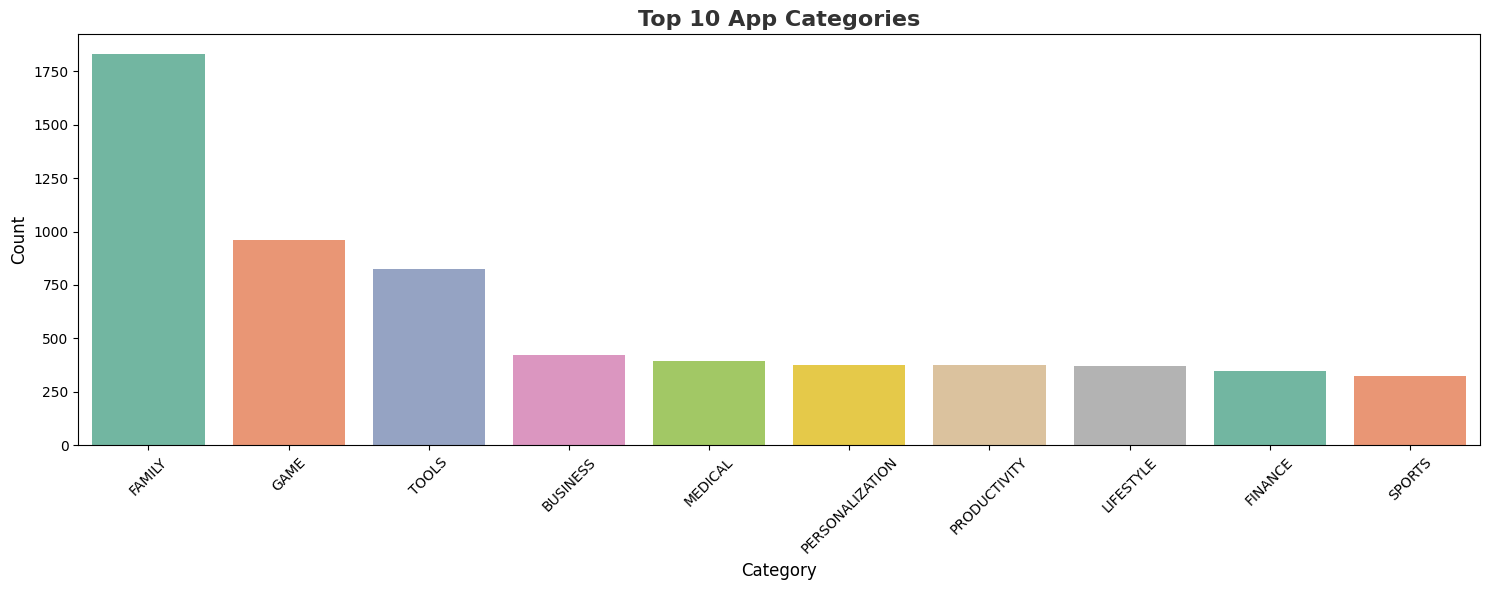

In [59]:
# Barchart
plt.figure(figsize=(15, 6))
sns.barplot(x=category.index[:10], y='count', data=category[:10], palette='Set2')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Top 10 App Categories', fontsize=16, fontweight='bold', alpha=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insights: Family and Game categories dominate the Google Play Store, indicating a strong demand for apps in these categories. Developers may want to focus on creating apps in these popular categories to maximize their reach and potential user base. However, there may also be opportunities in less saturated categories like Beauty, Events, Parenting, and Comics for developers looking to target niche markets.

## Which category has largest number of installs?


In [61]:
df_copy.columns

Index(['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size',
       'Installs', 'Price', 'Content Rating', 'Genres', 'Released',
       'Current Ver', 'Android Ver', 'Day', 'Month', 'Year'],
      dtype='str')

In [62]:
df_cat_installs = df_copy.groupby('Category')['Installs'].sum().reset_index()
df_cat_installs.rename(columns={'Installs': 'Total_Installs'}, inplace=True)
df_cat_installs.sort_values(by='Total_Installs', ascending=False, inplace=True)
df_cat_installs.head(10)

,Category,Total_Installs
14,GAME,13878924415
6,COMMUNICATION,11038276251
29,TOOLS,8001771915
25,PRODUCTIVITY,5793091369
27,SOCIAL,5487867902
24,PHOTOGRAPHY,4649147655
11,FAMILY,4427941505
31,VIDEO_PLAYERS,3926902720
30,TRAVEL_AND_LOCAL,2894887146
21,NEWS_AND_MAGAZINES,2369217760


## what are the top 5 most installed apps in each popular categories?

In [86]:
df_copy.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Price,Content Rating,Genres,Released,Current Ver,Android Ver,Day,Month,Year
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [ ]:
# Barchart for total installs by category
plt.figure(figsize=(15, 6))
sns.barplot(x='Category', y='Total_Installs', data=df_cat_installs[:10], palette='Set2')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Installs', fontsize=12)
plt.title('Total Installs by Category', fontsize=16, fontweight='bold', alpha=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Index(['App', 'Rating', 'Reviews', 'Size', 'Installs', 'Price',
       'Content Rating', 'Genres', 'Released', 'Current Ver', 'Android Ver',
       'Day', 'Month', 'Year'],
      dtype='str')

In [ ]:
## How many apps are there on Google Play Store which get 5 ratings?